In [1]:
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import DPOTrainer, DPOConfig, GRPOTrainer, GRPOConfig
from peft import LoraConfig, TaskType

--- Début de l'entraînement DPO (LoRA) ---


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
10,0.680420,0.695781


--- Début de l'entraînement GRPO (LoRA) ---


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
10,0.000000,0.000000


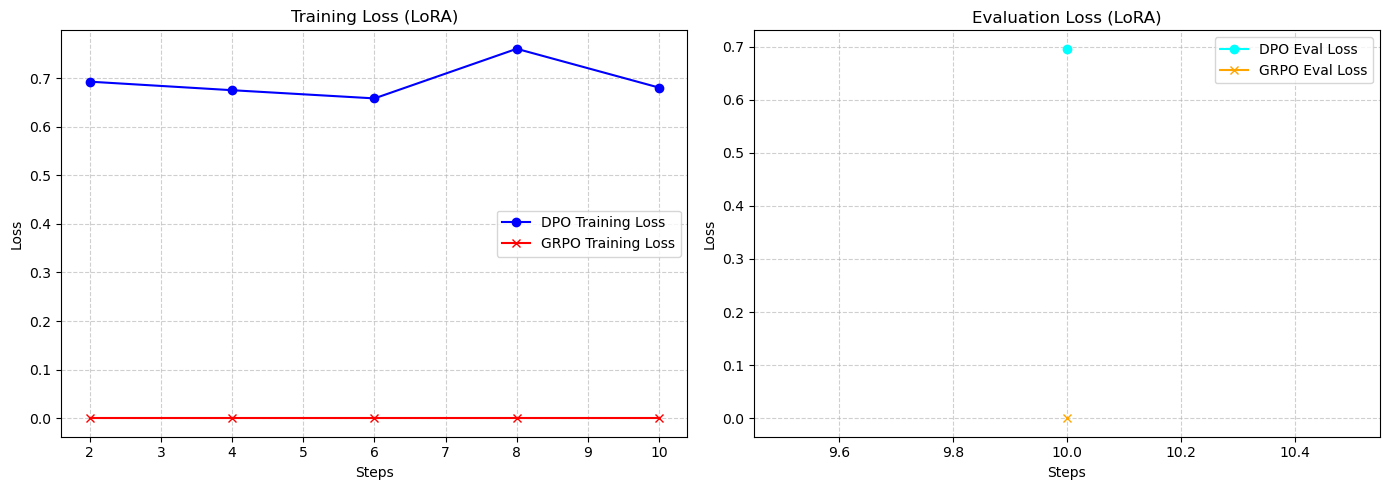

In [15]:
# ==========================================
# 1. Configuration initiale et LoRA
# ==========================================
model_id = "Qwen/Qwen2.5-0.5B"
dataset_name = "trl-lib/ultrafeedback_binarized" # Un dataset de démonstration avec des paires de questions-réponses
STEP = 10


tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Chargement d'un sous-ensemble
dataset = load_dataset(dataset_name, split="train[:500]")
dataset = dataset.train_test_split(test_size=0.1)

# Configuration LoRA minimaliste
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# ==========================================
# 2. Entraînement DPO avec LoRA
# ==========================================
print("--- Début de l'entraînement DPO (LoRA) ---")
model_dpo = AutoModelForCausalLM.from_pretrained(
    model_id, 
    device_map="cpu"
)

# 2. Configuration DPO adaptée au CPU
dpo_config = DPOConfig(
    output_dir="./results_dpo",
    beta=0.1,
    per_device_train_batch_size=1, # Réduit à 1. La valeur 2 provoquera probablement un OOM sur CPU.
    gradient_accumulation_steps=8, # Augmenté pour compenser la réduction du batch_size
    learning_rate=2e-4,
    max_steps=STEP,
    logging_steps=2,
    eval_steps=10,
    eval_strategy="steps", # <-- LIGNE CRUCIALE MANQUANTE
    do_eval=True,          # Force l'activation de l'évaluation
    remove_unused_columns=False,
    
    # Paramètres matériels stricts
    use_cpu=True,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False
)

dpo_trainer = DPOTrainer(
    model=model_dpo,
    args=dpo_config,
    peft_config=lora_config, # Injection de LoRA
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
)

dpo_trainer.train()
dpo_logs = dpo_trainer.state.log_history

del model_dpo
del dpo_trainer
torch.cuda.empty_cache()

# ==========================================
# 3. Entraînement RLHF (GRPO) avec LoRA
# ==========================================
print("--- Début de l'entraînement GRPO (LoRA) ---")
model_grpo = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")

def extract_prompt_for_grpo(example):
    chosen_data = example["chosen"]
    
    # Cas 1 : Le dataset utilise une liste de dictionnaires (Format ChatML / OpenAI)
    # Exemple : [{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]
    if isinstance(chosen_data, list) and len(chosen_data) > 0 and isinstance(chosen_data[0], dict):
        # On extrait tous les messages sauf la réponse finale de l'assistant
        prompt_only = [msg for msg in chosen_data[:-1]]
        return {"prompt": prompt_only}
        
    # Cas 2 : Le dataset utilise une chaîne de caractères brute (String)
    elif isinstance(chosen_data, str):
        # Attention : Cette méthode dépend de ton gabarit exact. 
        # Si ton texte est formaté avec des balises comme "### Instruction:" ou "[INST]", 
        # il faut scinder la chaîne pour ne garder que la requête.
        # Exemple hypothétique (à adapter) :
        # prompt_only = chosen_data.split("### Response:")[0].strip()
        
        # Fallback temporaire s'il n'y a pas de délimiteur clair
        prompt_only = chosen_data 
        return {"prompt": prompt_only}
        
    else:
        raise ValueError(f"Format non reconnu dans la colonne 'chosen': {type(chosen_data)}")

# Application de la transformation
dataset = dataset.map(extract_prompt_for_grpo)

# Suppression optionnelle des colonnes inutiles pour libérer la RAM sur ton CPU
dataset = dataset.remove_columns(["chosen", "rejected", "score_chosen", "score_rejected"])

def length_reward_func(completions, **kwargs):
    rewards = []
    target_len = 125 # Cible idéale au milieu de [50, 200]
    
    for c in completions:
        length = len(c)
        # Calcule l'écart par rapport à la cible. Plus on est loin, plus la récompense baisse.
        # Utilisation d'une fonction exponentielle négative pour la lisser entre 0.0 et 1.0
        diff = abs(length - target_len)
        reward = 1.0 * (0.99 ** diff) 
        rewards.append(reward)
        
    return rewards

model_grpo.generation_config.do_sample = True
model_grpo.generation_config.temperature = 0.9

grpo_config = GRPOConfig(
    output_dir="./results_grpo",
    learning_rate=5e-5,
    
    # Réduction drastique pour survivre sur la RAM du CPU
    per_device_train_batch_size=1, 
    gradient_accumulation_steps=8, # Augmenté pour lisser le gradient
    num_generations=4, # Limite la taille du groupe G à 4 au lieu de 8
    
    max_steps=STEP,
    logging_steps=2,
    eval_steps=10,
    eval_strategy="steps", # <-- LIGNE CRUCIALE MANQUANTE
    do_eval=True,          # Force l'activation de l'évaluation
    
    # Forcer l'exécution sur CPU et désactiver la précision matérielle GPU
    use_cpu=True,
    fp16=False,
    bf16=False,
    dataloader_pin_memory=False
)

grpo_trainer = GRPOTrainer(
    model=model_grpo,
    reward_funcs=length_reward_func,
    args=grpo_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=lora_config,
)

grpo_trainer.train()
grpo_logs = grpo_trainer.state.log_history

# ==========================================
# 4. Traçage des performances
# ==========================================
def extract_metric(logs, metric_name):
    steps = [log["step"] for log in logs if metric_name in log]
    values = [log[metric_name] for log in logs if metric_name in log]
    return steps, values

dpo_steps, dpo_loss = extract_metric(dpo_logs, "loss")
dpo_eval_steps, dpo_eval_loss = extract_metric(dpo_logs, "eval_loss")

grpo_steps, grpo_loss = extract_metric(grpo_logs, "loss")
grpo_eval_steps, grpo_eval_loss = extract_metric(grpo_logs, "eval_loss")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(dpo_steps, dpo_loss, label='DPO Training Loss', marker='o', color='blue')
ax1.plot(grpo_steps, grpo_loss, label='GRPO Training Loss', marker='x', color='red')
ax1.set_title('Training Loss (LoRA)')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(dpo_eval_steps, dpo_eval_loss, label='DPO Eval Loss', marker='o', color='cyan')
ax2.plot(grpo_eval_steps, grpo_eval_loss, label='GRPO Eval Loss', marker='x', color='orange')
ax2.set_title('Evaluation Loss (LoRA)')
ax2.set_xlabel('Steps')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("dpo_vs_grpo_lora_performance.png")
plt.show()